In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
from fbm import FBM
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy.optimize import curve_fit
import scipy.special as sp
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from scipy.special import gamma,beta
font = {'size': 30, 'weight':'normal'}
plt.rc('font', **font)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "text.latex.preamble": r"\usepackage{amssymb}",
})
rng = np.random.default_rng(seed=42)
colors = [['blue',"slateblue"], ['darkgoldenrod', "goldenrod"], ['olivedrab', "yellowgreen"], ['red', "indianred",], ['plum',"pink"], ['black','dimgray'], ['orangered','coral'] ]
import matplotlib.ticker as ticker

# SATW Figures

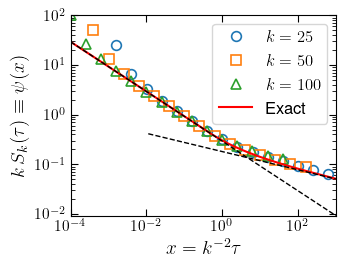

In [15]:

# --- Parameters ---
dw = 2
beta = 1
phi = 1/np.e
theta = np.exp(-beta)/2

# --- PRL figure size: half column (~3.4 inch width) ---
fig, ax = plt.subplots(figsize=(3.4, 2.6))

markers = ['o', 's', '^']
colors = ['C0', 'C1', 'C2']

# --- Numerical data ---
for i, x0 in enumerate([25, 50, 100]):
    Times = np.logspace(0, 6, 16)[:-1]
    Ti = []

    for s in os.listdir(f'Data/SATRW_1e6/{x0}'):
        Ti += list(np.load(f'Data/SATRW_1e6/{x0}/{s}'))

    Ti = np.array(Ti)
    Ti = Ti[Ti > 0]

    Sl = np.array([np.sum(Ti >= ti) / len(Ti) for ti in Times])

    ax.plot(
        Times / x0**dw,
        x0 * Sl,
        marker=markers[i],
        linestyle='none',
        markersize=7,
        markerfacecolor='none',
        markeredgewidth=1.2,
        color=colors[i],
        label=rf'$k={x0}$'
    )

# --- Theory curve ---
s_th = np.loadtxt('Data/s-phi0.367879.csv')
tau_th = np.loadtxt('Data/tau-phi0.367879.csv')

asymp_largex = (2/tau_th)**(phi/2) * sp.gamma((1+phi)/2) / (np.sqrt(np.pi) * sp.beta(phi,phi))
asymp_smallx = phi * np.sqrt(2/np.pi/tau_th)

ax.plot(tau_th, s_th, color='red', linewidth=1.5, label='Exact')
ax.plot(tau_th[tau_th > 1e-2], asymp_largex[tau_th > 1e-2],
          'k--', linewidth=1)
ax.plot(tau_th, asymp_smallx,
          'k--', linewidth=1)



ax.set_xscale('log')
ax.set_yscale('log')

ax.tick_params(which='both', direction='in',
               top=True, right=True,
               labelsize=11)
ax.tick_params(which='major', length=5)
ax.tick_params(which='minor', length=3)

# --- Labels ---
ax.set_xlabel(r'$x=k^{-2}\tau$', fontsize=14)
ax.set_ylabel(r'$k\,S_k(\tau)\equiv \psi(x)$', fontsize=14)

plt.legend(fontsize=12,loc='best')
plt.tight_layout()

ax.margins(x=0, y=0)  # removes internal padding
plt.subplots_adjust(left=0.2, right=0.98, bottom=0.20, top=0.97)

plt.savefig('Figures/SATW_phiem1.pdf')
plt.show()

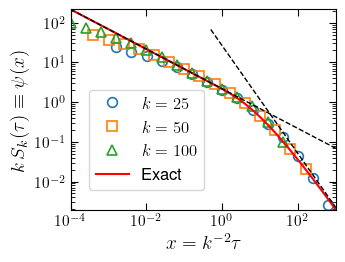

In [14]:
# --- Parameters ---
dw = 2
phi = np.e
beta = -1
theta = np.exp(-beta)/2

# --- PRL half-column size ---
fig, ax = plt.subplots(figsize=(3.4, 2.6))

markers = ['o', 's', '^']
colors = ['C0', 'C1', 'C2']

# --- Numerical data ---
for i, x0 in enumerate([25, 50, 100]):
    Times = np.logspace(0, 6, 16)[:-1]
    Ti = []

    for s in os.listdir(f'Data/SATRW_m1_1e6/{x0}'):
        Ti += list(np.load(f'Data/SATRW_m1_1e6/{x0}/{s}'))

    Ti = np.array(Ti)
    Ti = Ti[Ti > 0]

    Sl = np.array([np.sum(Ti >= ti) / len(Ti) for ti in Times])

    ax.loglog(
        Times / x0**dw,
        x0 * Sl,
        marker=markers[i],
        linestyle='none',
        markersize=7,
        markerfacecolor='none',
        markeredgewidth=1.2,
        color=colors[i],
        label=rf'$k={x0}$'
    )

# --- Theory ---
s_th = np.loadtxt('Data/s-phiE.csv')
tau_th = np.loadtxt('Data/tau-phiE.csv')

asymp_largex = (2/tau_th)**(phi/2) * sp.gamma((1+phi)/2) / \
               (np.sqrt(np.pi) * sp.beta(phi,phi))
asymp_smallx = phi * np.sqrt(2/np.pi/tau_th)

ax.loglog(tau_th, s_th, 'r-', linewidth=1.5, label='Exact')
ax.loglog(tau_th[tau_th > .5], asymp_largex[tau_th > .5],
          'k--', linewidth=1)
ax.loglog(tau_th, asymp_smallx,
          'k--', linewidth=1)


ax.tick_params(which='both', direction='in',
               top=True, right=True,
               labelsize=11)
ax.tick_params(which='major', length=5)
ax.tick_params(which='minor', length=3)

# --- Labels ---
ax.set_xlabel(r'$x=k^{-2}\tau$', fontsize=14)
ax.set_ylabel(r'$k\,S_k(\tau)\equiv \psi(x)$', fontsize=14)

plt.legend(fontsize=12,loc=(0.07,0.1))
plt.tight_layout()

ax.margins(x=0, y=0)  # removes internal padding
plt.subplots_adjust(left=0.2, right=0.98, bottom=0.20, top=0.97)

plt.savefig('Figures/SATW_phie.pdf')
plt.show()